# ML-10 - Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hisham-Walid/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This notebook turns the validated Week-5 ranking model into a **human review queue**, not an automated publishing system. The model orders candidates; transparent rules add an action, archetype, reason codes, effort band, safeguards, and monitoring policy. All claims are limited to the March 2026 analysis sample.

## 1. Ranked actions + reason codes

The queue is built only from the six clients held out in ML-09. Each candidate was therefore scored by a model that did not train on that client. Features end on March 20; March 21-31 outcomes create the retrospective target. June stays sealed.

The model supplies **rank order**, while deterministic, inspectable rules supply the suggested action:

| Archetype | Observable pattern at decision time | Suggested human review | Typical effort |
|---|---|---|---|
| Page-one under-capture | Position 4-10 and CTR below the training-client peer rate | `SNIPPET_INTENT_REVIEW` - inspect intent, title, and description | Low: under 1 hour |
| Striking-distance under-capture | Position 11-20 and CTR below its peer rate | `CONTENT_REFRESH_REVIEW` - inspect freshness, coverage, and internal links | Medium: 2-4 hours |
| Deep but visible | Position worse than 20 with high modeled opportunity | `RELEVANCE_DIAGNOSIS` - inspect query/page fit before editing | Medium: 1-2 hours |
| Top-three asset | Position 1-3 | `PROTECT_AND_MONITOR` - avoid unnecessary rewrite | Low: under 30 minutes |
| Thin evidence | Fewer than 10 active feature-window days | `MONITOR_MORE_DATA` - collect more history first | Low: under 30 minutes |
| No specific rule | Remaining visible candidates | `MONITOR` - retain in the next review cycle | Low: under 30 minutes |

Reason codes name the measured evidence: `HIGH_MODELED_OPPORTUNITY`, `HIGH_VISIBILITY`, `PAGE_ONE`, `STRIKING_DISTANCE`, `CTR_BELOW_TRAIN_PEER`, and `THIN_HISTORY`. They explain why a row entered the queue; they do not claim that an edit will produce clicks.

In [1]:
import json
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import ndcg_score
from sklearn.model_selection import GroupShuffleSplit

RANDOM_SEED = 42
FEATURE_START = '2026-03-01'
DECISION_DATE = '2026-03-20'
OUTCOME_START = '2026-03-21'
OUTCOME_END = '2026-03-31'
MIN_CLIENT_ROWS = 100
K = 20
QUEUE_PER_CLIENT = 10

repo_root = Path.cwd().resolve()
while not (repo_root / 'work' / 'notebooks').exists():
    if repo_root.parent == repo_root:
        raise FileNotFoundError('Run this notebook from somewhere inside the repository.')
    repo_root = repo_root.parent
output_dir = repo_root / 'work' / 'outputs'
figure_dir = repo_root / 'work' / 'figures'
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
local_file = os.getenv('FLYRANK_MARCH_PARQUET')
hf_token = os.getenv('HF_TOKEN')
if local_file and Path(local_file).is_file():
    escaped = Path(local_file).as_posix().replace("'", "''")
    FACT = f"read_parquet('{escaped}')"
    source_mode = 'authenticated local cache'
elif hf_token:
    escaped_token = hf_token.replace("'", "''")
    con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{escaped_token}')")
    FACT = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')"
    source_mode = 'authenticated Hugging Face stream'
else:
    raise RuntimeError('Set HF_TOKEN or FLYRANK_MARCH_PARQUET; never paste a token into this notebook.')

query = f"""
WITH daily AS (
    SELECT report_date, client_hash_id, content_hash_id,
           gsc_impressions, gsc_clicks, gsc_sum_position
    FROM {FACT}
    WHERE gsc_data_available IS TRUE
), prior AS (
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS prior_impressions,
           SUM(gsc_clicks) AS prior_clicks,
           SUM(gsc_sum_position) / NULLIF(SUM(gsc_impressions), 0) AS prior_avg_position,
           COUNT(*) FILTER (WHERE gsc_impressions > 0) AS prior_active_days,
           100.0 * SUM(gsc_clicks) / NULLIF(SUM(gsc_impressions), 0) AS prior_ctr_pct
    FROM daily
    WHERE report_date BETWEEN DATE '{FEATURE_START}' AND DATE '{DECISION_DATE}'
    GROUP BY 1, 2
    HAVING SUM(gsc_impressions) >= 100
), outcome AS (
    SELECT client_hash_id, content_hash_id,
           SUM(gsc_impressions) AS future_impressions,
           SUM(gsc_clicks) AS future_clicks,
           SUM(gsc_sum_position) / NULLIF(SUM(gsc_impressions), 0) AS future_avg_position,
           100.0 * SUM(gsc_clicks) / NULLIF(SUM(gsc_impressions), 0) AS future_ctr_pct
    FROM daily
    WHERE report_date BETWEEN DATE '{OUTCOME_START}' AND DATE '{OUTCOME_END}'
    GROUP BY 1, 2
    HAVING SUM(gsc_impressions) > 0
)
SELECT p.*, o.* EXCLUDE (client_hash_id, content_hash_id)
FROM prior p
JOIN outcome o USING (client_hash_id, content_hash_id)
"""
frame = con.execute(query).df()
eligible = frame.groupby('client_hash_id').size()
eligible = eligible[eligible >= MIN_CLIENT_ROWS].index
frame = frame.loc[frame['client_hash_id'].isin(eligible)].copy()
frame = frame.sort_values(['client_hash_id', 'content_hash_id']).reset_index(drop=True)

features = [
    'prior_impressions', 'prior_clicks', 'prior_avg_position',
    'prior_active_days', 'prior_ctr_pct',
]
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)
train_idx, test_idx = next(splitter.split(frame, groups=frame['client_hash_id']))
train, test = frame.iloc[train_idx].copy(), frame.iloc[test_idx].copy()
assert set(train['client_hash_id']).isdisjoint(set(test['client_hash_id']))

position_bins = [-np.inf, 3, 10, 20, 50, np.inf]
position_labels = ['top_3', 'page_1', 'striking', 'page_3_5', 'deep']
for part in (train, test):
    part['future_position_band'] = pd.cut(
        part['future_avg_position'], bins=position_bins, labels=position_labels
    )
train_future_peer = train.groupby('future_position_band', observed=True).agg(
    impressions=('future_impressions', 'sum'), clicks=('future_clicks', 'sum')
)
train_future_peer['expected_future_ctr_pct'] = (
    100 * train_future_peer['clicks'] / train_future_peer['impressions']
)
for part in (train, test):
    part['expected_future_ctr_pct'] = (
        part['future_position_band'].map(train_future_peer['expected_future_ctr_pct']).astype(float)
    )
    part['future_ctr_gap_pp'] = (
        part['expected_future_ctr_pct'] - part['future_ctr_pct']
    ).clip(lower=0)
    part['future_missed_clicks'] = (
        part['future_impressions'] * part['future_ctr_gap_pp'] / 100
    )

model = RandomForestRegressor(
    n_estimators=200, max_depth=10, min_samples_leaf=20,
    max_features=0.8, random_state=RANDOM_SEED, n_jobs=-1,
)
model.fit(train[features], np.log1p(train['future_missed_clicks']))
test['model_score'] = np.expm1(model.predict(test[features])).clip(min=0)

client_ndcg = [
    ndcg_score(
        [group['future_missed_clicks'].to_numpy()],
        [group['model_score'].to_numpy()], k=K,
    )
    for _, group in test.groupby('client_hash_id')
]
grouped_median_ndcg = float(np.median(client_ndcg))

prior_bins = [-np.inf, 3, 10, 20, np.inf]
prior_labels = ['top_3', 'page_1', 'striking', 'deep']
for part in (train, test):
    part['prior_position_band'] = pd.cut(
        part['prior_avg_position'], bins=prior_bins, labels=prior_labels
    )
train_prior_peer = train.groupby('prior_position_band', observed=True).agg(
    impressions=('prior_impressions', 'sum'), clicks=('prior_clicks', 'sum')
)
train_prior_peer['peer_ctr_pct'] = 100 * train_prior_peer['clicks'] / train_prior_peer['impressions']
test['peer_ctr_pct'] = test['prior_position_band'].map(train_prior_peer['peer_ctr_pct']).astype(float)
test['ctr_gap_to_train_peer_pp'] = (test['peer_ctr_pct'] - test['prior_ctr_pct']).clip(lower=0)

visibility_threshold = float(train['prior_impressions'].quantile(0.75))
test['score_percentile_in_client'] = test.groupby('client_hash_id')['model_score'].rank(pct=True)

def classify_action(row):
    if row['prior_active_days'] < 10:
        return 'Thin evidence', 'MONITOR_MORE_DATA', 'Low: <30 min'
    if row['prior_avg_position'] <= 3:
        return 'Top-three asset', 'PROTECT_AND_MONITOR', 'Low: <30 min'
    if 4 <= row['prior_avg_position'] <= 10 and row['ctr_gap_to_train_peer_pp'] > 0:
        return 'Page-one under-capture', 'SNIPPET_INTENT_REVIEW', 'Low: <1 hour'
    if 10 < row['prior_avg_position'] <= 20 and row['ctr_gap_to_train_peer_pp'] > 0:
        return 'Striking-distance under-capture', 'CONTENT_REFRESH_REVIEW', 'Medium: 2-4 hours'
    if row['prior_avg_position'] > 20 and row['score_percentile_in_client'] >= 0.80:
        return 'Deep but visible', 'RELEVANCE_DIAGNOSIS', 'Medium: 1-2 hours'
    return 'No specific rule', 'MONITOR', 'Low: <30 min'

def reason_codes(row):
    reasons = []
    if row['score_percentile_in_client'] >= 0.80:
        reasons.append('HIGH_MODELED_OPPORTUNITY')
    if row['prior_impressions'] >= visibility_threshold:
        reasons.append('HIGH_VISIBILITY')
    if 4 <= row['prior_avg_position'] <= 10:
        reasons.append('PAGE_ONE')
    if 10 < row['prior_avg_position'] <= 20:
        reasons.append('STRIKING_DISTANCE')
    if row['ctr_gap_to_train_peer_pp'] > 0:
        reasons.append('CTR_BELOW_TRAIN_PEER')
    if row['prior_active_days'] < 10:
        reasons.append('THIN_HISTORY')
    return '|'.join(reasons) if reasons else 'VISIBLE_MONITORING_CANDIDATE'

test[['archetype', 'suggested_action', 'effort_band']] = test.apply(
    classify_action, axis=1, result_type='expand'
)
test['reason_codes'] = test.apply(reason_codes, axis=1)

queue = (
    test.sort_values(['client_hash_id', 'model_score'], ascending=[True, False])
    .groupby('client_hash_id', group_keys=False)
    .head(QUEUE_PER_CLIENT)
    .copy()
)
queue['rank_within_client'] = queue.groupby('client_hash_id')['model_score'].rank(
    method='first', ascending=False
).astype(int)
queue['value_tier'] = pd.qcut(
    queue['model_score'].rank(method='first'), q=3, labels=['Directional', 'Medium', 'High']
)
queue['human_review_required'] = True
queue = queue.sort_values(['rank_within_client', 'model_score'], ascending=[True, False]).reset_index(drop=True)

preview = queue[
    ['rank_within_client', 'suggested_action', 'archetype', 'reason_codes',
     'effort_band', 'value_tier', 'model_score']
].head(15)
print(f'Built from {len(frame):,} eligible pages via {source_mode}; {test.client_hash_id.nunique()} unseen clients.')
print(f'Grouped median client NDCG@20: {grouped_median_ndcg:.3f}; queue: {len(queue)} candidates.')
print('Public preview (identifiers intentionally omitted):')
display(preview.style.format({'model_score': '{:.2f}'}))

Built from 86,574 eligible pages via authenticated local cache; 6 unseen clients.
Grouped median client NDCG@20: 0.797; queue: 60 candidates.
Public preview (identifiers intentionally omitted):


,rank_within_client,suggested_action,archetype,reason_codes,effort_band,value_tier,model_score
0,1,SNIPPET_INTENT_REVIEW,Page-one under-capture,HIGH_MODELED_OPPORTUNITY|HIGH_VISIBILITY|PAGE_ONE|CTR_BELOW_TRAIN_PEER,Low: <1 hour,High,34.69
1,1,SNIPPET_INTENT_REVIEW,Page-one under-capture,HIGH_MODELED_OPPORTUNITY|HIGH_VISIBILITY|PAGE_ONE|CTR_BELOW_TRAIN_PEER,Low: <1 hour,High,15.64
2,1,SNIPPET_INTENT_REVIEW,Page-one under-capture,HIGH_MODELED_OPPORTUNITY|HIGH_VISIBILITY|PAGE_ONE|CTR_BELOW_TRAIN_PEER,Low: <1 hour,High,13.22
3,1,SNIPPET_INTENT_REVIEW,Page-one under-capture,HIGH_MODELED_OPPORTUNITY|HIGH_VISIBILITY|PAGE_ONE|CTR_BELOW_TRAIN_PEER,Low: <1 hour,High,10.58
4,1,SNIPPET_INTENT_REVIEW,Page-one under-capture,HIGH_MODELED_OPPORTUNITY|HIGH_VISIBILITY|PAGE_ONE|CTR_BELOW_TRAIN_PEER,Low: <1 hour,Medium,6.55
5,1,SNIPPET_INTENT_REVIEW,Page-one under-capture,HIGH_MODELED_OPPORTUNITY|PAGE_ONE|CTR_BELOW_TRAIN_PEER,Low: <1 hour,Medium,3.14
6,2,SNIPPET_INTENT_REVIEW,Page-one under-capture,HIGH_MODELED_OPPORTUNITY|HIGH_VISIBILITY|PAGE_ONE|CTR_BELOW_TRAIN_PEER,Low: <1 hour,High,13.53
7,2,SNIPPET_INTENT_REVIEW,Page-one under-capture,HIGH_MODELED_OPPORTUNITY|HIGH_VISIBILITY|PAGE_ONE|CTR_BELOW_TRAIN_PEER,Low: <1 hour,High,11.58
8,2,SNIPPET_INTENT_REVIEW,Page-one under-capture,HIGH_MODELED_OPPORTUNITY|HIGH_VISIBILITY|PAGE_ONE|CTR_BELOW_TRAIN_PEER,Low: <1 hour,High,9.40
9,2,SNIPPET_INTENT_REVIEW,Page-one under-capture,HIGH_MODELED_OPPORTUNITY|HIGH_VISIBILITY|PAGE_ONE|CTR_BELOW_TRAIN_PEER,Low: <1 hour,Medium,6.23


## 2. Intended use, decay/refresh insight, cost, and limits

### Intended use

A content strategist uses this queue **weekly** to decide which visible pages deserve manual diagnosis first. It is a prioritization aid, not a content-quality label and not a promise of recovered clicks. Review should happen within each client because the queue takes ten candidates per held-out client rather than letting the largest portfolio dominate.

### Decay and refresh

The FlyRank March 2026 research paper observed that mature, recently refreshed pages showed stronger health and impressions than mature stale pages. That comparison was observational and could include selection bias. This warehouse slice has no content-age or last-update field, so the model does not infer decay. For `CONTENT_REFRESH_REVIEW`, the editor must look up publish/update history in the CMS and compare the page with an untreated peer. “Refresh” means investigate stale facts, missing coverage, intent drift, and internal links - not lengthen a page automatically.

### Cost/value interpretation

`model_score` is a ranking score on the missed-click target scale, not guaranteed incremental clicks or money. `value_tier` is relative within this 60-row queue. Effort bands are planning ranges for **review**, not measured production costs. The editor should prefer high directional value with low review effort, but brand risk and evidence quality override the score.

### Limits

The evidence is one March month, 86,574 eligible pages, and six unseen held-out clients. Pages needed at least 100 prior impressions, an observed outcome impression, and a client with at least 100 eligible rows. This survivorship condition excludes disappearing and very low-volume pages. The system has no query intent, CMS freshness, content quality, legal risk, conversion value, or intervention history. It must not be generalized to new periods or automatic editing without forward validation.

In [2]:
operating_contract = pd.DataFrame([
    ('User', 'Content strategist or SEO analyst'),
    ('Decision', 'Which visible pages receive manual diagnosis first'),
    ('Cadence', 'Weekly review; monthly outcome audit'),
    ('Unit', 'Ten candidates per held-out client'),
    ('Evidence', 'Pre-decision GSC aggregates plus grouped-holdout model score'),
    ('Excluded', 'Causal uplift, revenue, quality, query intent, CMS freshness'),
    ('Override', 'Human reviewer can defer or reject every suggestion'),
])
operating_contract.columns = ['contract_item', 'statement']

action_summary = queue.groupby(
    ['suggested_action', 'effort_band'], as_index=False, observed=True
).agg(candidates=('suggested_action', 'size'), median_score=('model_score', 'median'))
action_summary['share_pct'] = 100 * action_summary['candidates'] / len(queue)

display(operating_contract)
display(action_summary.style.format({'median_score': '{:.2f}', 'share_pct': '{:.1f}%'}))
assert queue.groupby('client_hash_id').size().eq(QUEUE_PER_CLIENT).all()
assert queue['human_review_required'].all()

,contract_item,statement
0,User,Content strategist or SEO analyst
1,Decision,Which visible pages receive manual diagnosis f...
2,Cadence,Weekly review; monthly outcome audit
3,Unit,Ten candidates per held-out client
4,Evidence,Pre-decision GSC aggregates plus grouped-holdo...
5,Excluded,"Causal uplift, revenue, quality, query intent,..."
6,Override,Human reviewer can defer or reject every sugge...


,suggested_action,effort_band,candidates,median_score,share_pct
0,CONTENT_REFRESH_REVIEW,Medium: 2-4 hours,4,2.16,6.7%
1,MONITOR,Low: <30 min,6,6.47,10.0%
2,MONITOR_MORE_DATA,Low: <30 min,5,2.03,8.3%
3,PROTECT_AND_MONITOR,Low: <30 min,4,2.65,6.7%
4,SNIPPET_INTENT_REVIEW,Low: <1 hour,41,4.54,68.3%


## 3. Human review + the no-go list

Before acting, a reviewer must:

1. Confirm the page is indexed, current, and still strategically relevant.
2. Inspect the actual query and intent mix; page-level aggregates cannot reveal intent mismatch or cannibalization.
3. Check CMS age, last update, recent releases, campaigns, outages, migrations, and seasonality.
4. Compare the page with an appropriate peer and confirm the CTR gap is not explained by SERP features or branded/non-branded mix.
5. Review brand, legal, editorial, accessibility, localization, and subject-matter constraints.
6. Choose an action, record the reason and reviewer, and define a 30/60-day measurement plan. A valid outcome includes “no change.”

### No-go list - never automate from this queue

- Publishing or rewriting titles, metadata, or body copy.
- Deleting, pruning, merging, redirecting, or de-indexing a page.
- Treating a low score as “bad content” or penalizing an author/client.
- Claiming an edit caused or will cause traffic, ranking, revenue, or AI-referral uplift.
- Acting on protected, legal, medical, financial, news, or high-brand-risk content without the responsible specialist.
- Exposing client/content identifiers, raw queries, credentials, or private URLs in public outputs.
- Retraining, replacing, or promoting a model solely because a monitoring threshold fired.

In [3]:
review_gates = pd.DataFrame([
    ('evidence', 'Enough clean history and no known outage/migration?', 'Defer when uncertain'),
    ('intent', 'Do queries and page purpose match the proposed action?', 'Change or reject action'),
    ('freshness', 'Do CMS dates or facts show a real refresh need?', 'Do not refresh by age alone'),
    ('risk', 'Any legal, brand, accessibility, or specialist review?', 'Escalate before editing'),
    ('measurement', 'Is a 30/60-day comparison and control peer defined?', 'Monitor before claiming lift'),
])
review_gates.columns = ['gate', 'review_question', 'safe_default']

no_go_actions = {
    'AUTO_PUBLISH', 'AUTO_DELETE', 'AUTO_REDIRECT', 'AUTO_DEINDEX',
    'AUTO_RETRAIN', 'AUTO_CLAIM_UPLIFT',
}
forbidden_export_columns = {
    'future_impressions', 'future_clicks', 'future_avg_position',
    'future_ctr_pct', 'future_ctr_gap_pp', 'future_missed_clicks',
}
assert no_go_actions.isdisjoint(set(queue['suggested_action']))
assert forbidden_export_columns.isdisjoint({
    'client_hash_id', 'content_hash_id', 'rank_within_client', 'suggested_action',
    'archetype', 'reason_codes', 'effort_band', 'value_tier',
    'model_score', 'prior_impressions', 'prior_clicks', 'prior_avg_position',
    'prior_active_days', 'prior_ctr_pct', 'human_review_required',
})
display(review_gates)
print('Policy assertions passed: every row requires human review; no destructive or outcome-derived field is authorized.')

,gate,review_question,safe_default
0,evidence,Enough clean history and no known outage/migra...,Defer when uncertain
1,intent,Do queries and page purpose match the proposed...,Change or reject action
2,freshness,Do CMS dates or facts show a real refresh need?,Do not refresh by age alone
3,risk,"Any legal, brand, accessibility, or specialist...",Escalate before editing
4,measurement,Is a 30/60-day comparison and control peer def...,Monitor before claiming lift


Policy assertions passed: every row requires human review; no destructive or outcome-derived field is authorized.


## 4. Monitoring / retrain triggers

This notebook implements a **test harness**, not a deployed monitor. Training-versus-held-out PSI below is a cross-client dry run, not temporal drift. In production, compare each new scoring window with the pinned March reference using the same feature definitions.

Operational policy:

- **Pause scoring:** schema/unit change, feature dates overlap the outcome window, data freshness exceeds 7 days, or usable page volume falls below 60% of reference.
- **Investigate:** PSI at least 0.10 for a core feature, positive-label base-rate shift of at least 10 percentage points after labels arrive, or one-client queue dominance above 25%.
- **Retrain review:** PSI at least 0.25 in two or more core features for two consecutive windows, or median client NDCG@20 falls by at least 0.10 in two labeled windows.
- **Do not auto-retrain:** a human first checks tracking, schema, seasonality, portfolio mix, and leakage; the replacement must beat the frozen baseline on a new grouped/forward holdout.

In [4]:
def population_stability_index(reference, current, bins=10):
    reference = np.asarray(reference, dtype=float)
    current = np.asarray(current, dtype=float)
    edges = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0
    edges[0], edges[-1] = -np.inf, np.inf
    ref_counts = np.histogram(reference, bins=edges)[0].astype(float)
    cur_counts = np.histogram(current, bins=edges)[0].astype(float)
    ref_share = np.clip(ref_counts / ref_counts.sum(), 1e-6, None)
    cur_share = np.clip(cur_counts / cur_counts.sum(), 1e-6, None)
    return float(np.sum((cur_share - ref_share) * np.log(cur_share / ref_share)))

drift_dry_run = pd.DataFrame({
    'feature': features,
    'psi_train_vs_unseen_clients': [
        population_stability_index(train[feature], test[feature]) for feature in features
    ],
})
drift_dry_run['dry_run_status'] = pd.cut(
    drift_dry_run['psi_train_vs_unseen_clients'],
    bins=[-np.inf, 0.10, 0.25, np.inf],
    labels=['stable', 'investigate', 'material'],
    right=False,
)

monitoring_policy = pd.DataFrame([
    ('Data freshness', '>7 days', 'Pause scoring; repair feed'),
    ('Usable page volume', '<60% of reference', 'Pause scoring; inspect coverage'),
    ('Single-feature PSI', '>=0.10', 'Investigate drift and mix'),
    ('Material PSI', '>=0.25 in 2+ features for 2 windows', 'Open retrain review'),
    ('Positive base rate', '>=10 pp shift', 'Recheck target and population'),
    ('Median client NDCG@20', '>=0.10 absolute drop for 2 windows', 'Compare frozen model and candidate'),
])
monitoring_policy.columns = ['signal', 'trigger', 'response']

display(drift_dry_run.style.format({'psi_train_vs_unseen_clients': '{:.3f}'}))
display(monitoring_policy)
print('Dry-run PSI is descriptive cross-client sensitivity; it does not trigger a production action.')

,feature,psi_train_vs_unseen_clients,dry_run_status
0,prior_impressions,0.456,material
1,prior_clicks,0.105,investigate
2,prior_avg_position,0.290,material
3,prior_active_days,0.109,investigate
4,prior_ctr_pct,0.233,investigate


,signal,trigger,response
0,Data freshness,>7 days,Pause scoring; repair feed
1,Usable page volume,<60% of reference,Pause scoring; inspect coverage
2,Single-feature PSI,>=0.10,Investigate drift and mix
3,Material PSI,>=0.25 in 2+ features for 2 windows,Open retrain review
4,Positive base rate,>=10 pp shift,Recheck target and population
5,Median client NDCG@20,>=0.10 absolute drop for 2 windows,Compare frozen model and candidate


Dry-run PSI is descriptive cross-client sensitivity; it does not trigger a production action.


## 5. Exports for the paper

The notebook regenerates three artifacts:

- `work/outputs/ml10_action_queue.csv` - 60 pseudonymous candidates, ignored by git as required by the leak guard.
- `work/outputs/ml10_playbook_metrics.json` - committed receipt for the paper's counts, evaluation number, action mix, and monitoring reference.
- `work/figures/ml10_action_mix.png` - committed paper-ready figure; it contains aggregated counts only.

The CSV contains no future outcome columns. Its identifiers exist only so an authorized reviewer can map a row back to the warehouse; they are never printed or committed.

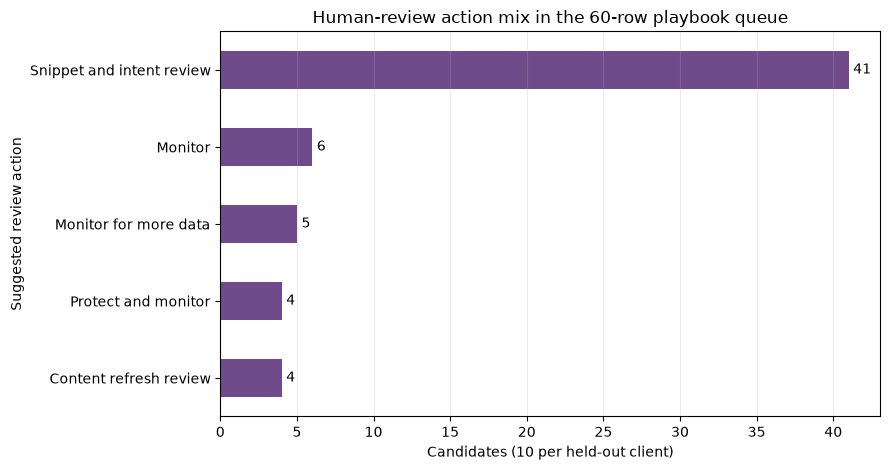

Exported ignored queue: work/outputs/ml10_action_queue.csv
Exported committed receipt: work/outputs/ml10_playbook_metrics.json
Exported committed figure: work/figures/ml10_action_mix.png


In [5]:
queue_export_columns = [
    'client_hash_id', 'content_hash_id', 'rank_within_client',
    'suggested_action', 'archetype', 'reason_codes', 'effort_band',
    'value_tier', 'model_score', 'prior_impressions', 'prior_clicks',
    'prior_avg_position', 'prior_active_days', 'prior_ctr_pct',
    'human_review_required',
]
assert forbidden_export_columns.isdisjoint(queue_export_columns)
assert queue[queue_export_columns].notna().all().all()

queue_path = output_dir / 'ml10_action_queue.csv'
queue[queue_export_columns].to_csv(queue_path, index=False)

action_display = {
    'SNIPPET_INTENT_REVIEW': 'Snippet and intent review',
    'CONTENT_REFRESH_REVIEW': 'Content refresh review',
    'RELEVANCE_DIAGNOSIS': 'Relevance diagnosis',
    'PROTECT_AND_MONITOR': 'Protect and monitor',
    'MONITOR_MORE_DATA': 'Monitor for more data',
    'MONITOR': 'Monitor',
}
plot_counts = queue['suggested_action'].value_counts().sort_values()
plot_counts.index = plot_counts.index.map(action_display)
fig, ax = plt.subplots(figsize=(9, 4.8))
plot_counts.plot.barh(ax=ax, color='#6f4b8b')
ax.set_title('Human-review action mix in the 60-row playbook queue')
ax.set_xlabel('Candidates (10 per held-out client)')
ax.set_ylabel('Suggested review action')
ax.grid(axis='x', alpha=0.25)
for index, value in enumerate(plot_counts):
    ax.text(value + 0.3, index, str(int(value)), va='center')
fig.tight_layout()
figure_path = figure_dir / 'ml10_action_mix.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
plt.show()

metrics = {
    'assignment': 'ML-10',
    'seed': RANDOM_SEED,
    'feature_window': [FEATURE_START, DECISION_DATE],
    'outcome_window': [OUTCOME_START, OUTCOME_END],
    'eligible_pages': int(len(frame)),
    'held_out_clients': int(test['client_hash_id'].nunique()),
    'queue_candidates': int(len(queue)),
    'candidates_per_client': QUEUE_PER_CLIENT,
    'grouped_median_client_ndcg_at_20': round(grouped_median_ndcg, 6),
    'human_review_required_pct': round(100 * queue['human_review_required'].mean(), 1),
    'action_mix': {str(k): int(v) for k, v in queue['suggested_action'].value_counts().sort_index().items()},
    'effort_mix': {str(k): int(v) for k, v in queue['effort_band'].value_counts().sort_index().items()},
    'drift_dry_run': drift_dry_run.assign(
        psi_train_vs_unseen_clients=drift_dry_run['psi_train_vs_unseen_clients'].round(6),
        dry_run_status=drift_dry_run['dry_run_status'].astype(str),
    ).to_dict(orient='records'),
    'policy_status': 'proposed_not_deployed',
    'queue_csv_committed': False,
    'versions': {
        'scikit_learn': sklearn.__version__,
        'pandas': pd.__version__,
        'duckdb': duckdb.__version__,
    },
}
metrics_path = output_dir / 'ml10_playbook_metrics.json'
metrics_path.write_text(json.dumps(metrics, indent=2) + '\n', encoding='utf-8')

print('Exported ignored queue: work/outputs/ml10_action_queue.csv')
print('Exported committed receipt: work/outputs/ml10_playbook_metrics.json')
print('Exported committed figure: work/figures/ml10_action_mix.png')

## 6. Self-check

- [x] Ranked queue includes a suggested action, archetype, transparent reason codes, effort/value context, and a per-client rank.
- [x] Intended user, decision, cadence, evidence boundary, survivorship condition, and override are explicit.
- [x] The decay/refresh insight is observational and requires CMS verification; it is not a causal promise.
- [x] Every row requires human review; destructive, sensitive, high-risk, and causal actions are on the no-go list.
- [x] Monitoring thresholds are concrete, but clearly labeled as proposed rather than deployed.
- [x] Retraining requires repeated evidence, a leakage check, a new honest holdout, and human approval.
- [x] The CSV is reproducible and ignored; the aggregate metrics receipt and figure are committed for the paper.
- [x] No client names, private URLs, raw queries, local paths, credentials, or outcome columns appear in public outputs.
- [x] Claims use observed, measured, directional, associated, and decision-support language.
- [x] All cells run top to bottom with a fixed seed and no errors.